# **Traffic Sign Recognition Using YOLO** - Implementation & Comparative Analysis

This assignment is an experimental implementation of YOLO on a simple dataset & also includes an analysis of the reference research work by comparing the performance of the YOLO models on the datasets (TT100K, CCTSDB, and HRRSD), both mentioned in the paper.

Dataset used for implementation: https://universe.roboflow.com/okokprojects/traffic-signs-dataset-in-yolo-format

Reference Paper: https://ieeexplore.ieee.org/document/10537684

Done by: Siddharth S. (25901335)

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt
!pip install roboflow

In [ ]:
from roboflow import Roboflow

In [ ]:
from IPython.display import Image

In [ ]:
import yaml
from collections import Counter
import glob

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

## **Load Dataset**

In [ ]:
rf = Roboflow(api_key="3uEescRXbm6VSoUEQ41C")
print(rf.workspace())

loading Roboflow workspace...
{
  "name": "New Workspace",
  "url": "siddharth-sudhakar",
  "projects": [
    "siddharth-sudhakar/traffic-signs-dataset-in-yolo-format-ki5bi"
  ]
}


In [ ]:
project = rf.workspace("siddharth-sudhakar").project("traffic-signs-dataset-in-yolo-format-ki5bi")
dataset = project.version(1).download("yolov5")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-signs-dataset-in-yolo-format-1 in yolov5pytorch:: 100%|██████████| 1492/1492 [00:00<00:00, 10173.27it/s]


In [ ]:
!ls

benchmarks.py	 hubconf.py	   segment
CITATION.cff	 LICENSE	   traffic-signs-dataset-in-yolo-format-1
classify	 models		   train.py
CONTRIBUTING.md  pyproject.toml    tutorial.ipynb
data		 README.md	   utils
detect.py	 README.zh-CN.md   val.py
export.py	 requirements.txt


## **Model Training and Evaluation**

In [ ]:
!python train.py \
  --img 416 \
  --batch 16 \
  --epochs 20 \
  --data /content/yolov5/traffic-signs-dataset-in-yolo-format-1/data.yaml \
  --weights yolov5s.pt \
  --name yolo_exp

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-27 11:31:44.940053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774611104.962376    1449 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774611104.969819    1449 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

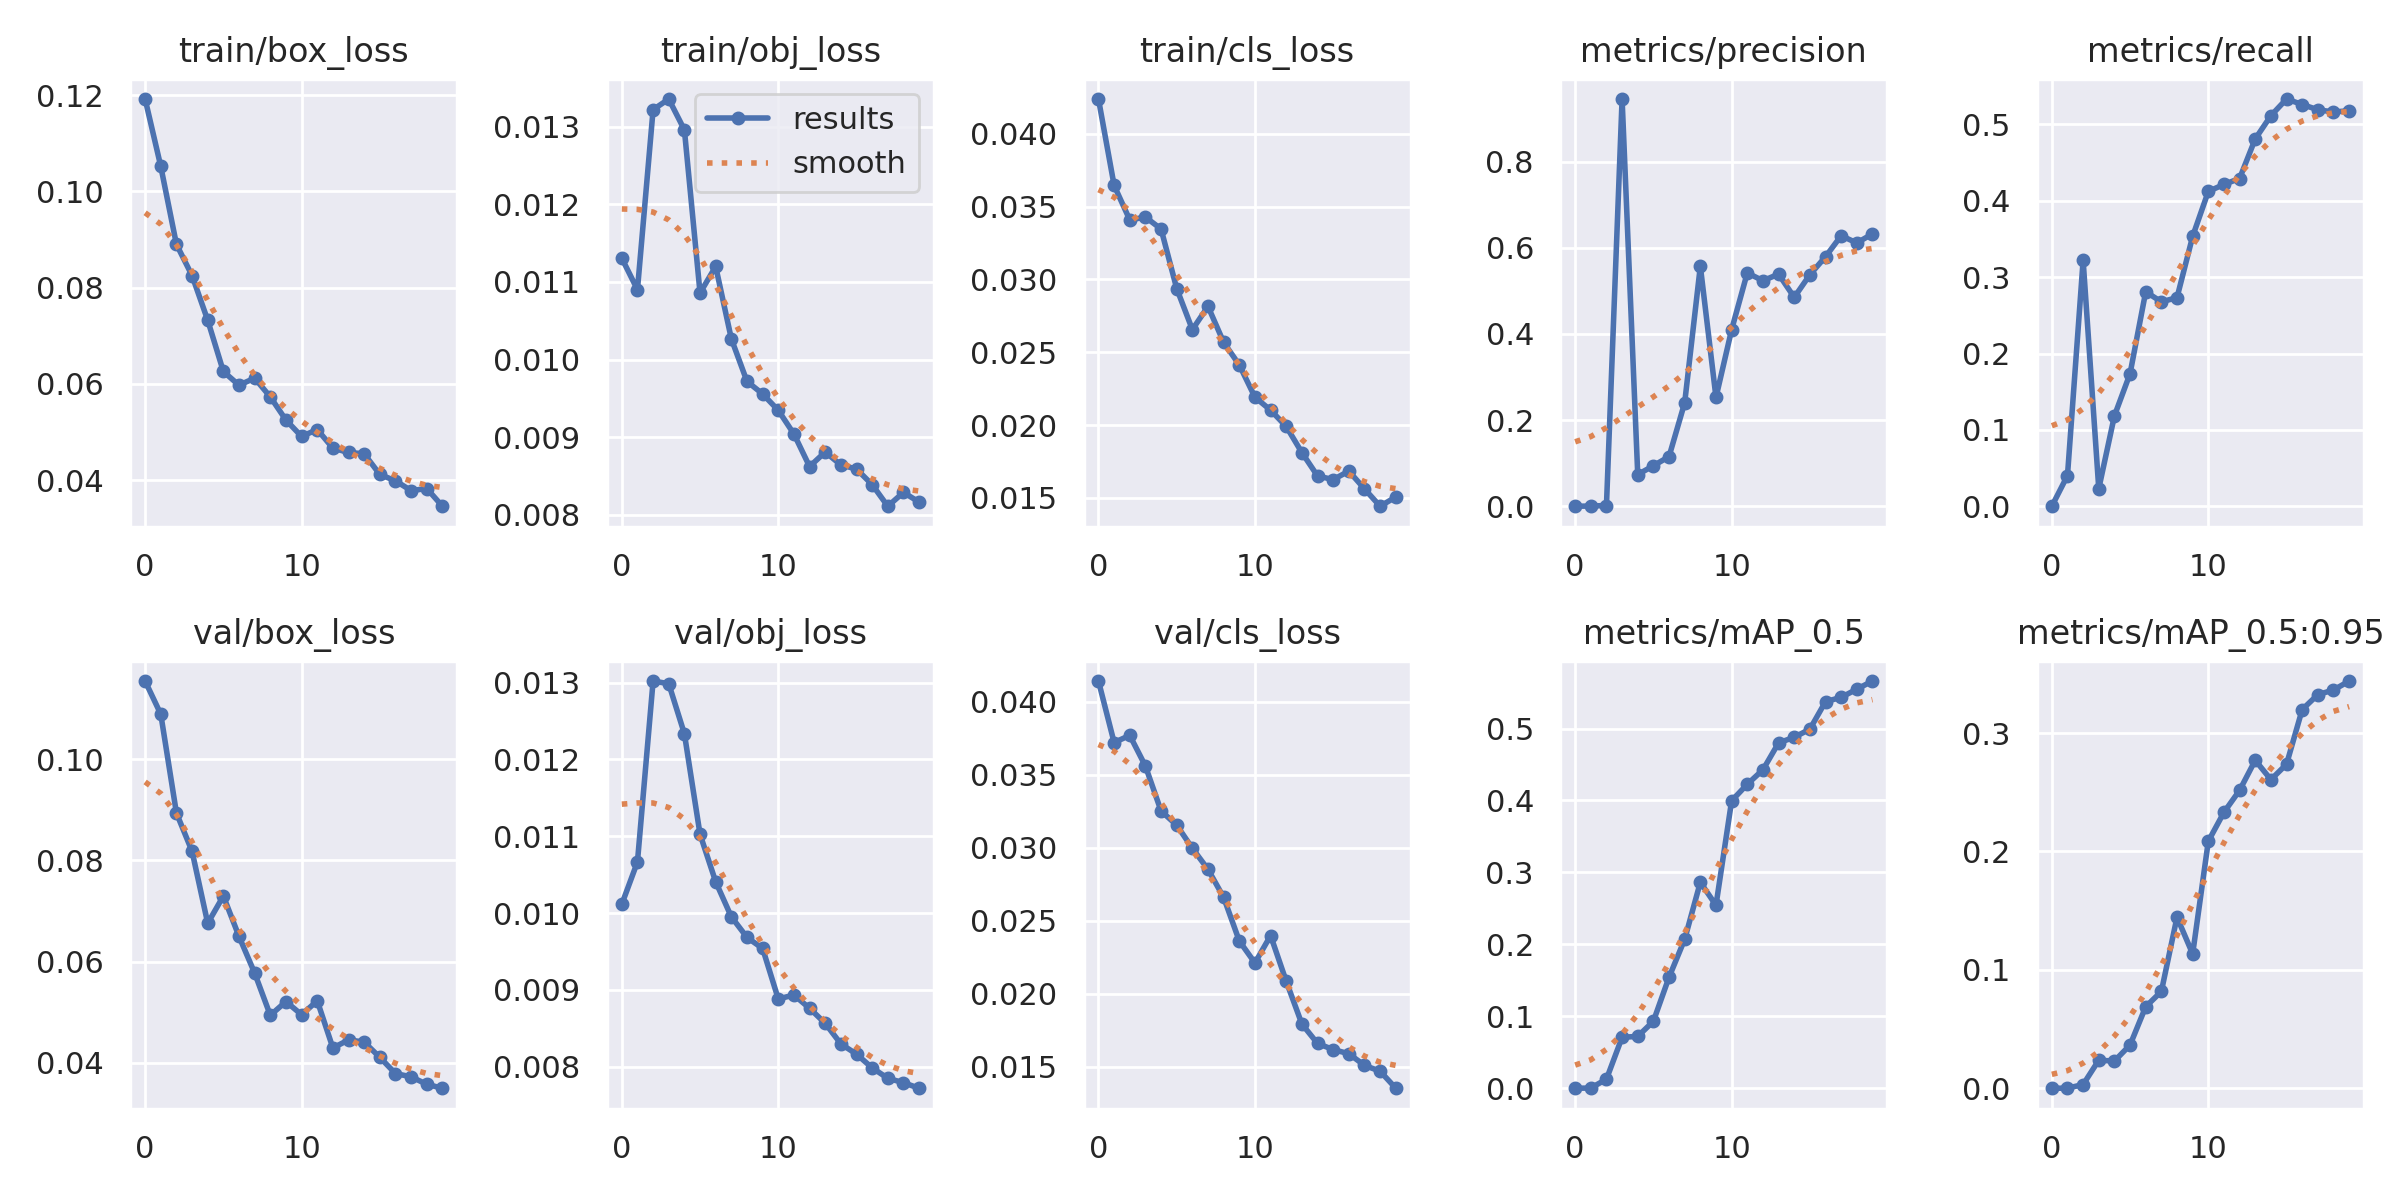

In [ ]:
Image(filename='runs/train/yolo_exp/results.png')

In [ ]:
!python val.py \
  --weights runs/train/yolo_exp/weights/best.pt \
  --data /content/yolov5/traffic-signs-dataset-in-yolo-format-1/data.yaml \
  --img 416

val: data=/content/yolov5/traffic-signs-dataset-in-yolo-format-1/data.yaml, weights=['runs/train/yolo_exp/weights/best.pt'], batch_size=32, imgsz=416, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/yolov5/traffic-signs-dataset-in-yolo-format-1/valid/labels.cache... 148 images, 0 backgrounds, 0 corrupt: 100% 148/148 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 5/5 [00:02<00:00,  2.27it/s]
                   all        148        228      0.635      0.519      0.565      0.343
                     0        148    

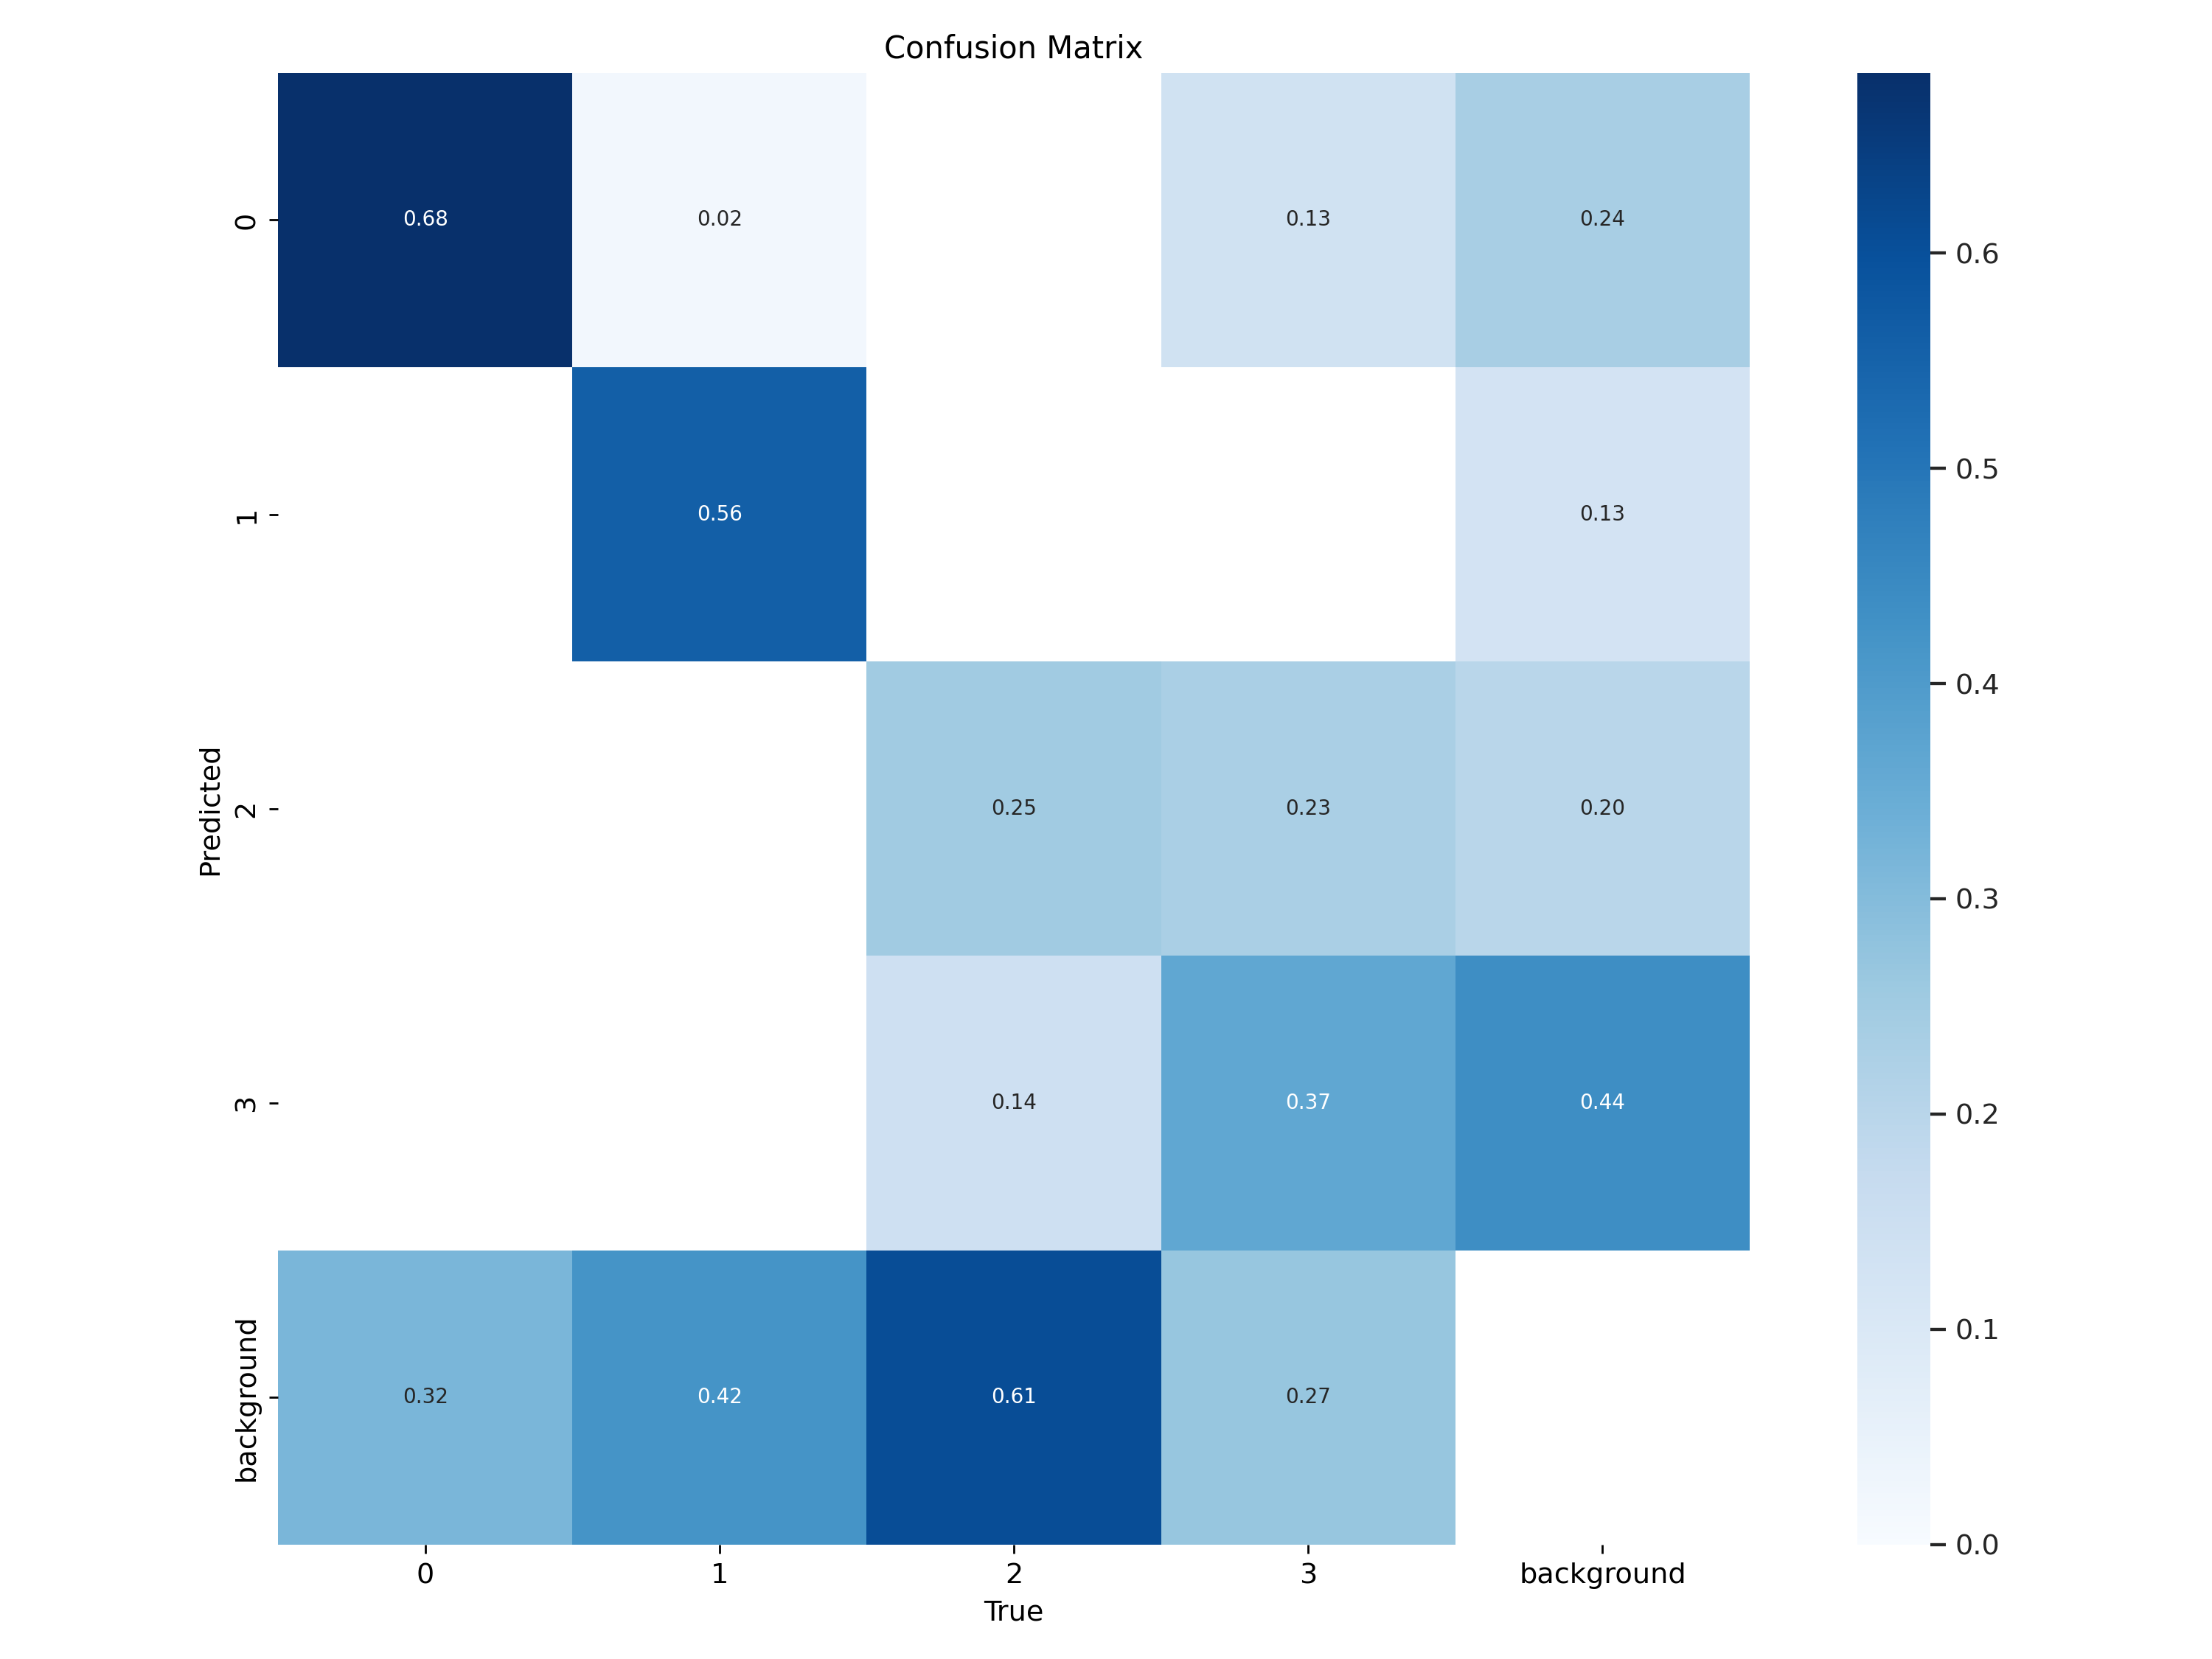

In [ ]:
Image(filename='runs/val/exp/confusion_matrix.png')

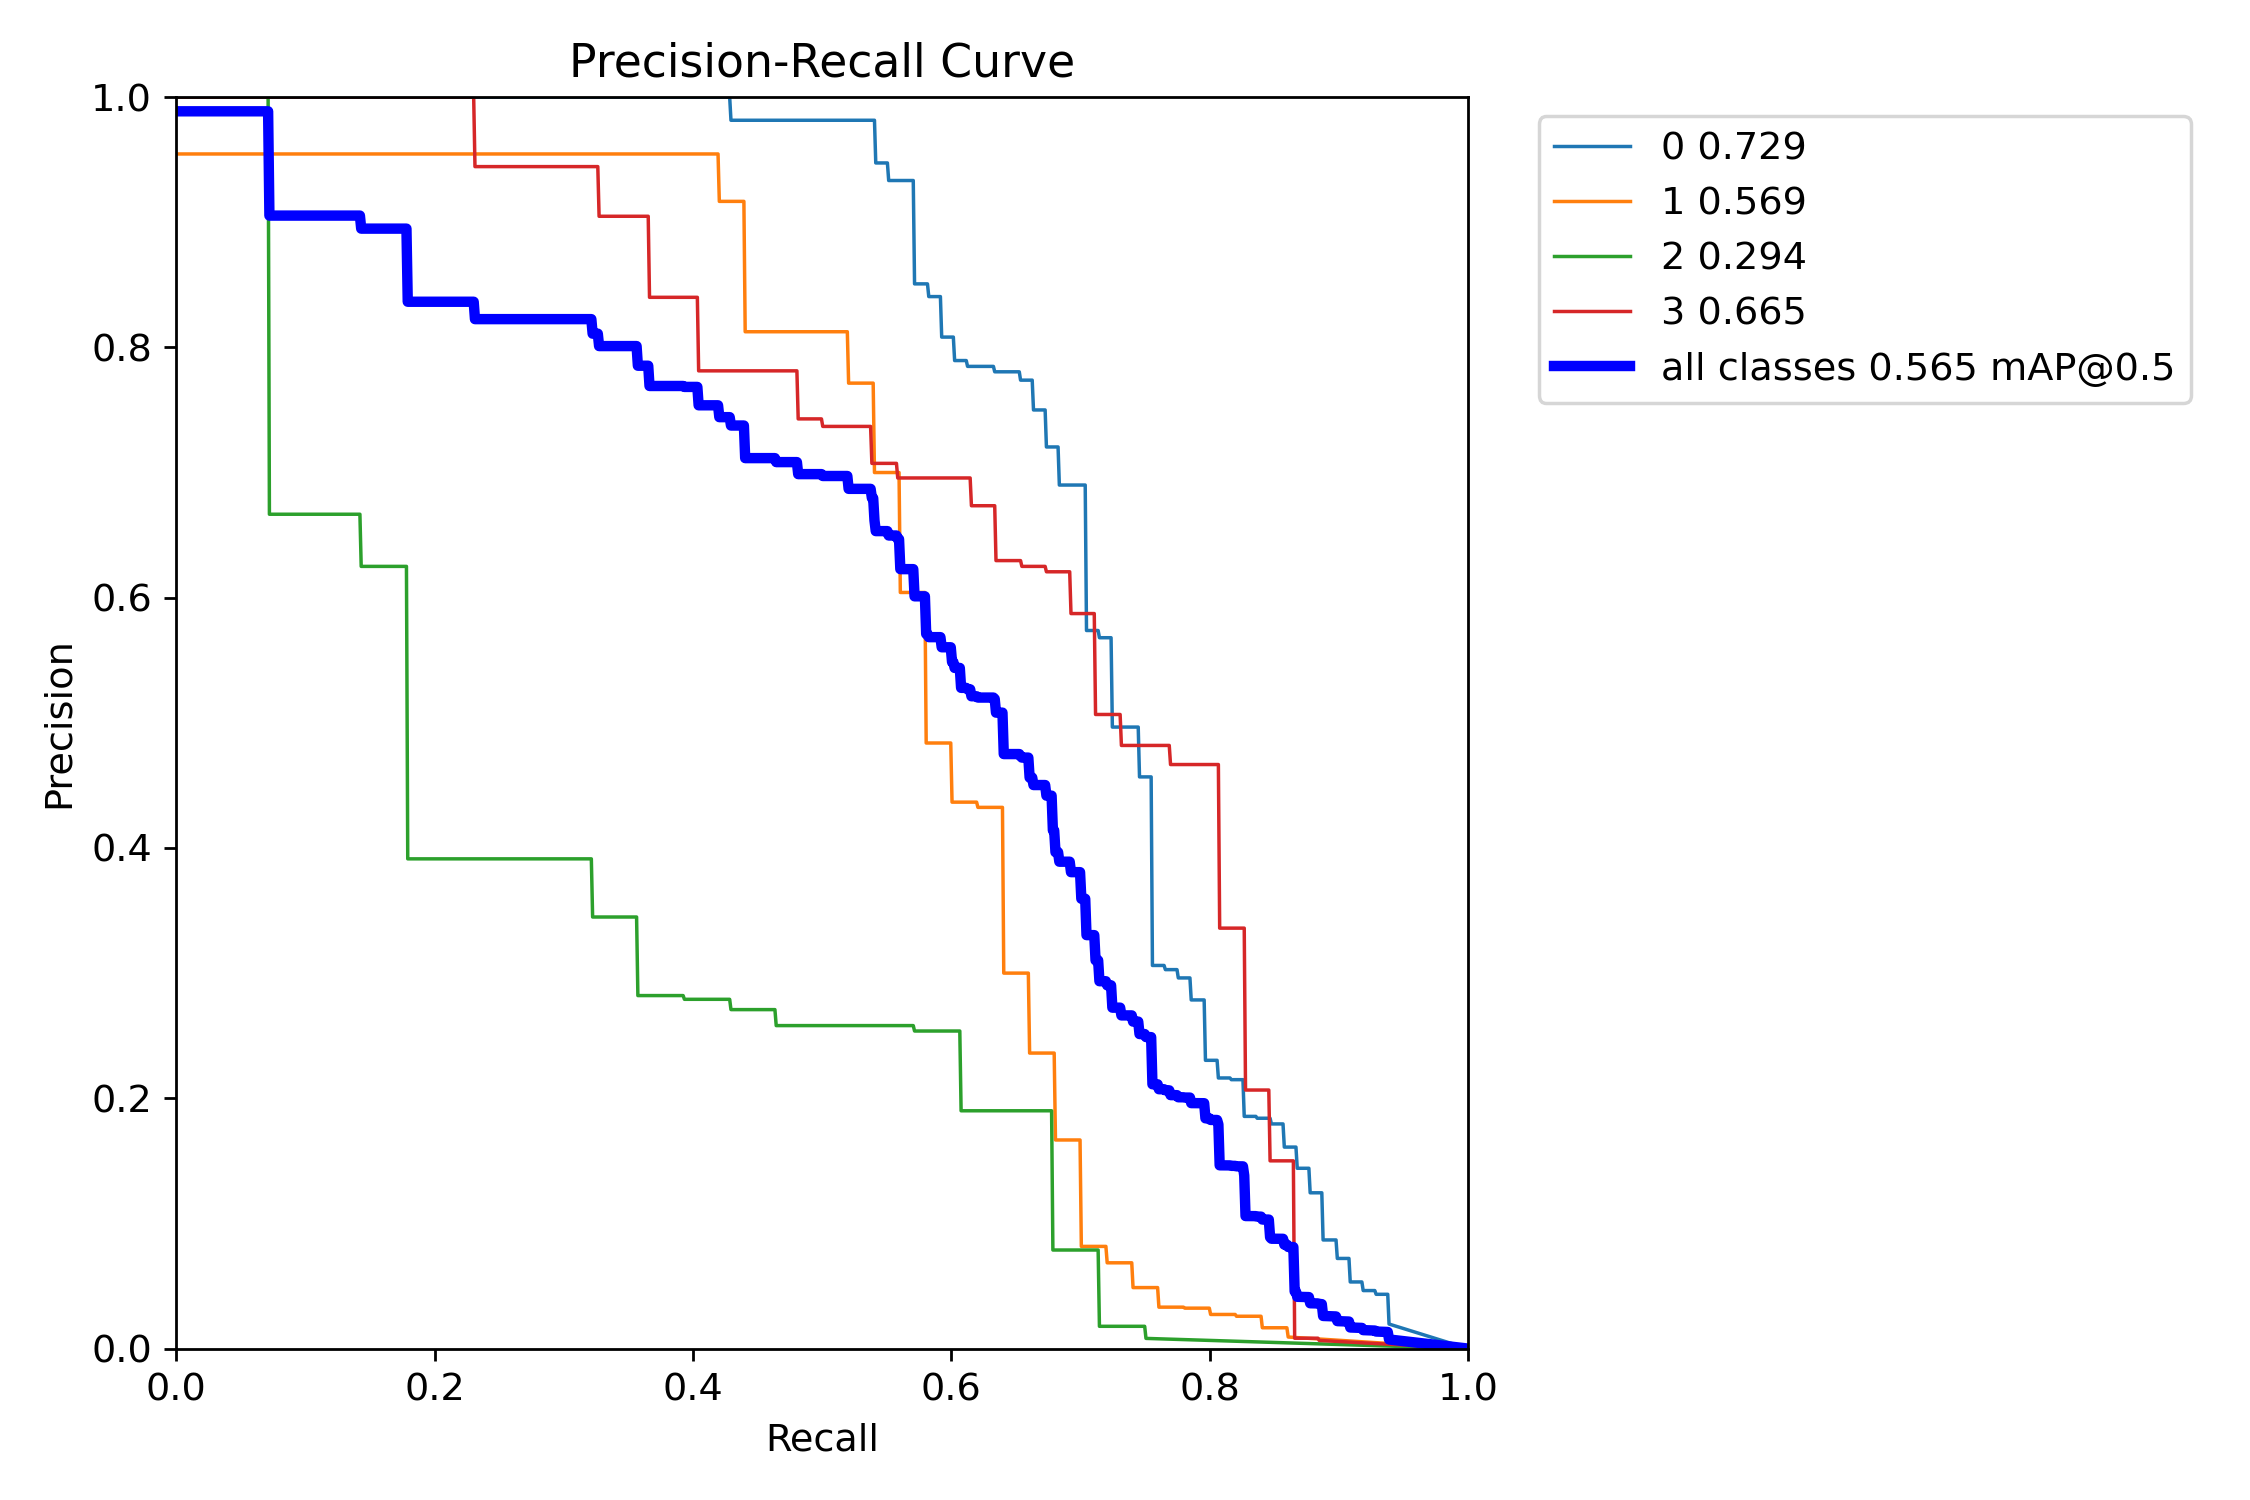

In [ ]:
Image(filename='runs/val/exp/PR_curve.png')

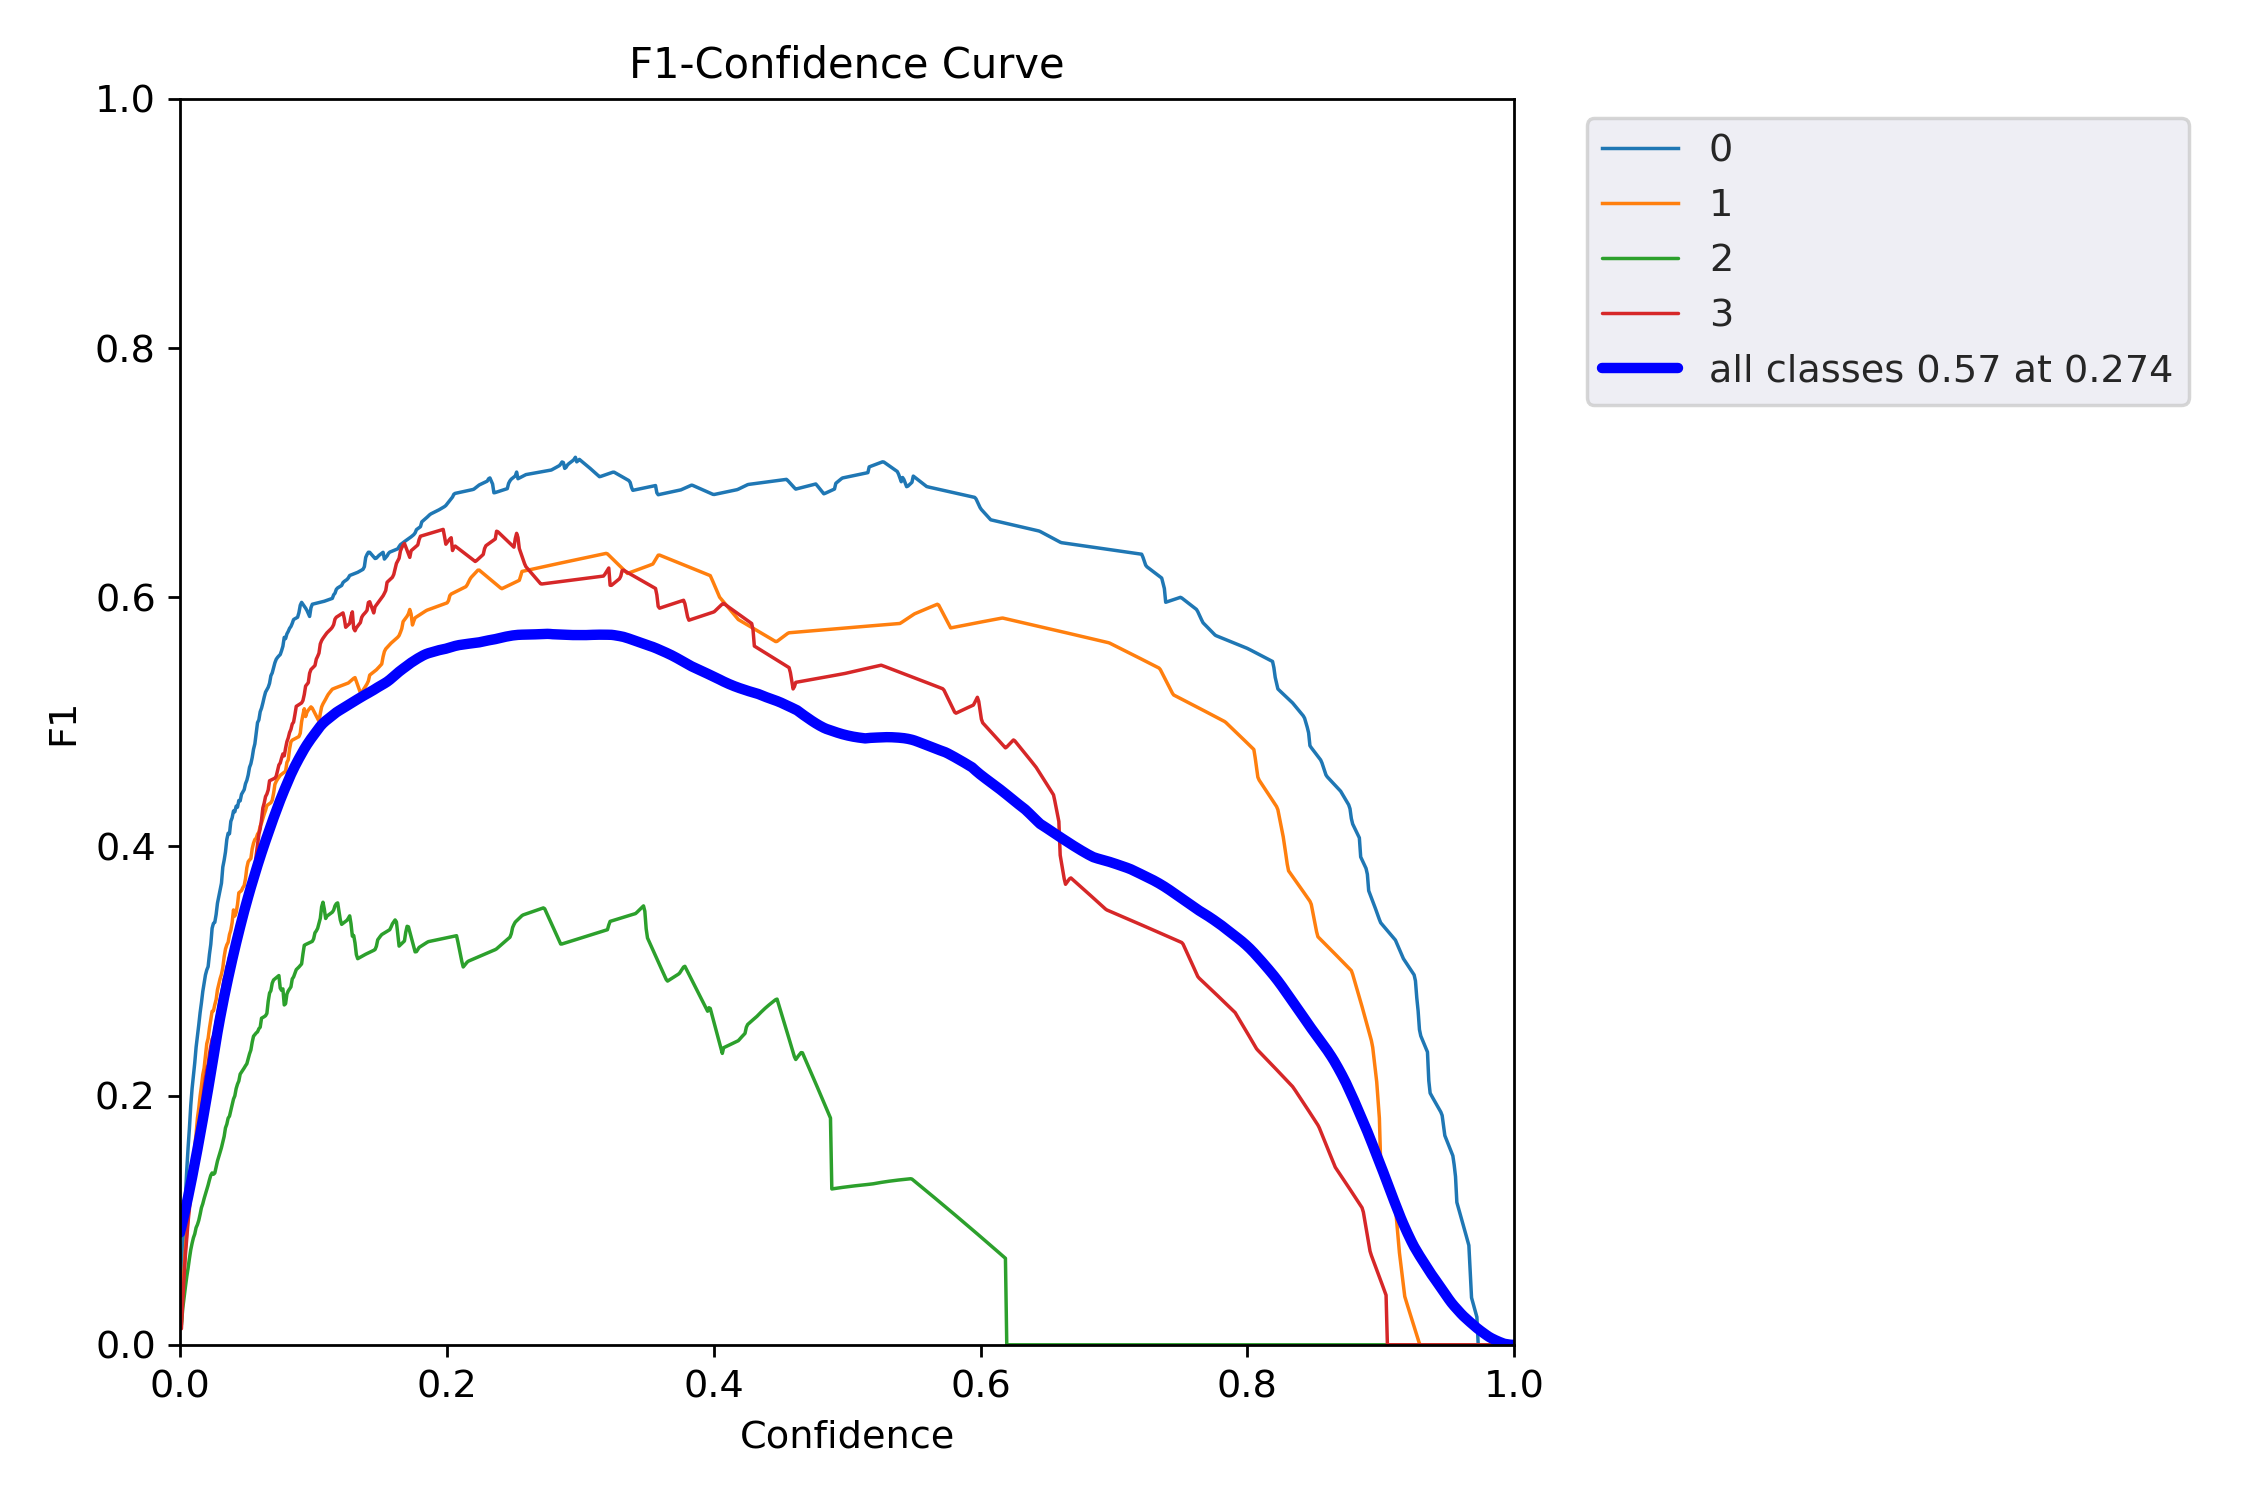

In [ ]:
Image(filename='runs/val/exp/F1_curve.png')

### Inference

In [ ]:
!python detect.py \
  --weights runs/train/yolo_exp/weights/best.pt \
  --img 416 \
  --source /content/yolov5/traffic-signs-dataset-in-yolo-format-1/test/images

detect: weights=['runs/train/yolo_exp/weights/best.pt'], source=/content/yolov5/traffic-signs-dataset-in-yolo-format-1/test/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/74 /content/yolov5/traffic-signs-dataset-in-yolo-format-1/test/images/00011_jpg.rf.de453de6c403b47f32a4f5244a996caf.jpg: 256x416 1 0, 1 1, 36.2ms
image 2/74 /content/yolov5/traffic-signs-dataset-in-yolo-format-1/test/images/00012_jpg.rf.31db926dc889e9c4

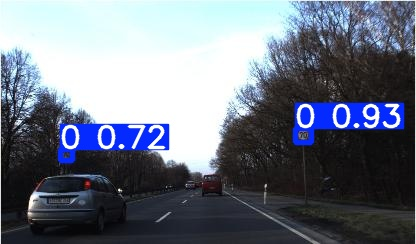

In [ ]:
Image(filename='runs/detect/exp/00895_jpg.rf.56b59876f86f70a33116c8ac3c1ebaba.jpg')

### Class Distribution of Data

In [ ]:
labels_path = "/content/yolov5/traffic-signs-dataset-in-yolo-format-1/train/labels"

class_counts = Counter()

for file in glob.glob(labels_path + "/*.txt"):
    with open(file) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

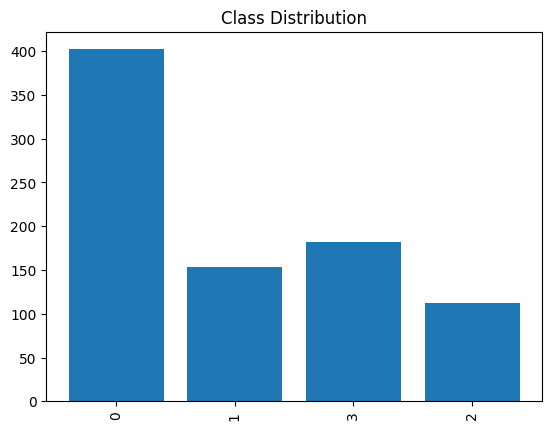

In [ ]:
with open("/content/yolov5/traffic-signs-dataset-in-yolo-format-1/data.yaml") as f:
    data = yaml.safe_load(f)

names = data['names']

plt.bar([names[i] for i in class_counts.keys()], class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

## **Comparative Analysis of Reference Paper's Outputs**

In [ ]:
paper_data = {
    "Model": ["YOLOv3", "YOLOv4", "YOLOv5"],
    "Dataset": ["CCTSDB", "CCTSDB", "CCTSDB"],
    "mAP": [96, 95.8, 95.4],
    "FPS": [73, 78, 85],
    "Precision": [88.1, 88.1, 84.9],
    "Recall": [94.6, 92.8, 95.2]
}

In [ ]:
df = pd.DataFrame(paper_data)

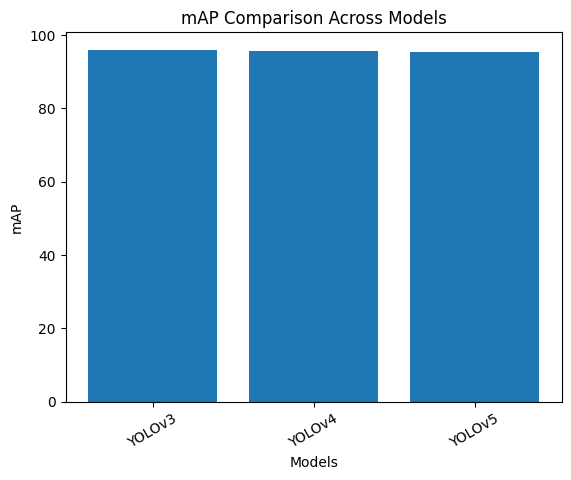

In [ ]:
plt.figure()
plt.bar(df["Model"], df["mAP"])
plt.title("mAP Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("mAP")
plt.xticks(rotation=30)
plt.show()

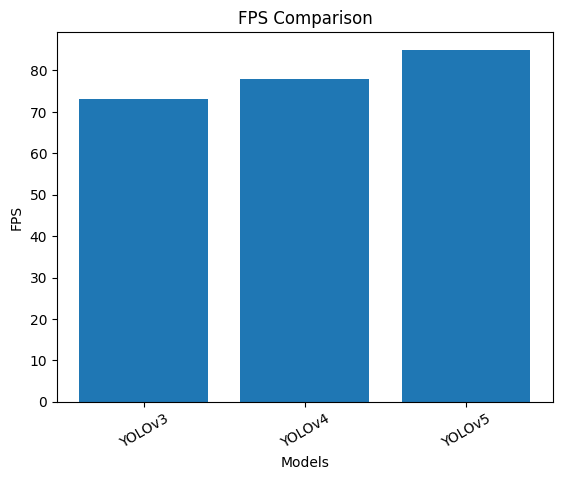

In [ ]:
plt.figure()
plt.bar(df["Model"], df["FPS"])
plt.title("FPS Comparison")
plt.xlabel("Models")
plt.ylabel("FPS")
plt.xticks(rotation=30)
plt.show()

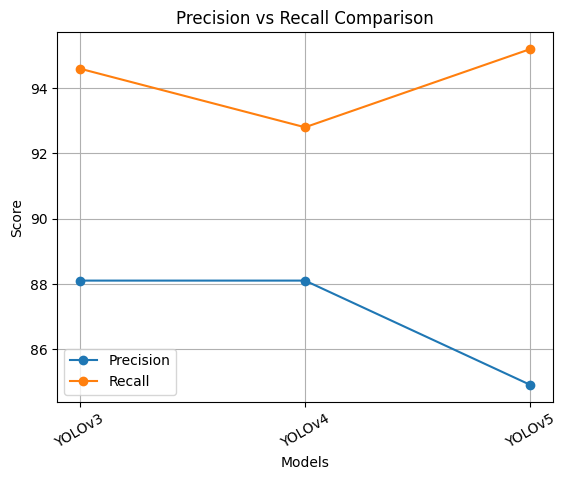

In [ ]:
plt.figure()
plt.plot(df["Model"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Model"], df["Recall"], marker='o', label="Recall")

plt.legend()
plt.title("Precision vs Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid()
plt.show()

In [ ]:
df["Score"] = (
    0.5 * df["mAP"] +
    0.3 * df["Precision"] +
    0.2 * df["Recall"]
)

ranking = df.sort_values(by="Score", ascending=False)

print("Final Ranking of Models:")
display(ranking)

Final Ranking of Models:


,Model,Dataset,mAP,FPS,Precision,Recall,Score
0,YOLOv3,CCTSDB,96.0,73,88.1,94.6,93.35
1,YOLOv4,CCTSDB,95.8,78,88.1,92.8,92.89
2,YOLOv5,CCTSDB,95.4,85,84.9,95.2,92.21
